# Artificial Intelligence Project

**Project Topic:** Malware Detection - [Microsoft Malware Prediction dataset](https://www.kaggle.com/competitions/microsoft-malware-prediction)

**Description:** Malware Detection by using Decision Tree (baseline) and RandomForest (ensemble). Compare result of 2 models

**Student Group:**
| Student ID | Student Fullname |
| -------- | ------- |
| 22302421 | Nguyễn Phúc Minh Châu |
| 22205801 | Huỳnh Thế Bảo |
| 22402742 | Nguyễn Phước Mai Bảo||

## Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

## 1. Data Collection

### Reduce Dataset Size

Because the Microsoft Malware Prediction data file contains 8,921,483 rows of data in the training file intended for concise malware detection and comparison of two machine learning models, the data will be compressed to 20,000 rows using standardized label sampling. This ensures that the data is not too small for accurate machine learning and minimizes the risk of missing rare labels in the data file.

In [2]:
chunks = []
chunk_size = 500000
frac = 20000 / 8921483

for chunk in pd.read_csv('microsoft-malware-prediction/train.csv', chunksize=chunk_size, low_memory=False):
    sampled_chunk = chunk.sample(frac=frac, random_state=42)
    chunks.append(sampled_chunk)

df = pd.concat(chunks, ignore_index=True)
print(df.shape)
df

(20002, 83)


,MachineIdentifier,ProductName,EngineVersion,AppVersion,AvSigVersion,IsBeta,RtpStateBitfield,IsSxsPassiveMode,DefaultBrowsersIdentifier,AVProductStatesIdentifier,...,Census_FirmwareVersionIdentifier,Census_IsSecureBootEnabled,Census_IsWIMBootEnabled,Census_IsVirtualDevice,Census_IsTouchEnabled,Census_IsPenCapable,Census_IsAlwaysOnAlwaysConnectedCapable,Wdft_IsGamer,Wdft_RegionIdentifier,HasDetections
0,0300dc2f2db485b7b34cc5e978b4c315,win8defender,1.1.15200.1,4.18.1807.18075,1.275.500.0,0,7.0,0,NaN,53447.0,...,35257.0,0,NaN,0.0,0,0,0.0,0.0,1.0,0
1,05bef370373ecd072617002fafd03fe0,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1734.0,0,7.0,0,NaN,53447.0,...,8124.0,0,NaN,1.0,0,1,0.0,0.0,3.0,0
2,040827af52225190fed8045cecd85846,win8defender,1.1.15200.1,4.18.1807.18075,1.275.866.0,0,7.0,0,NaN,53447.0,...,6882.0,1,0.0,0.0,0,0,0.0,0.0,1.0,1
3,03d1b40368ae2cf5571a0ca7ad289388,win8defender,1.1.15200.1,4.13.17134.1,1.273.1420.0,0,7.0,0,NaN,47238.0,...,13156.0,1,NaN,0.0,0,0,0.0,1.0,1.0,1
4,0bc02d7ebb83f79b3e4958ffe3d76689,win8defender,1.1.13504.0,4.11.15063.1155,1.237.0.0,0,7.0,0,2725.0,53447.0,...,13171.0,1,NaN,0.0,0,0,0.0,0.0,3.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19997,f6a2ce6594e598466caef4b393fa64b8,win8defender,1.1.15100.1,4.18.1807.18075,1.273.612.0,0,7.0,0,NaN,53447.0,...,16701.0,0,0.0,0.0,0,0,0.0,1.0,15.0,0
19998,fd3ec94f56710570ba1d74fe8c3e2748,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1642.0,0,7.0,0,NaN,53447.0,...,25262.0,1,NaN,0.0,0,0,0.0,0.0,1.0,1
19999,fb7045bd5be62831a97113cdf9a934f8,win8defender,1.1.15200.1,4.9.10586.873,1.275.59.0,0,7.0,0,NaN,53447.0,...,63122.0,0,0.0,0.0,0,0,0.0,0.0,15.0,1
20000,fd1e2a8a19c394bb74a9cb8df8bedce8,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1527.0,0,7.0,0,NaN,53447.0,...,20388.0,0,NaN,0.0,0,0,0.0,0.0,10.0,0


## 2. Data Processing

In [6]:
num_duplicates = df.duplicated().sum()
if num_duplicates > 0:
    df = df.drop_duplicates(keep="first")
    print(
        f"--- [Drop Duplicates] Đã xóa {num_duplicates} dòng bị trùng lặp hoàn toàn."
    )
else:
    print("--- [Drop Duplicates] Không có dòng nào bị trùng lặp hoàn toàn.")

--- [Drop Duplicates] Không có dòng nào bị trùng lặp hoàn toàn.


### 2.1. Handeling Missing Data

PuaMode                                              99.965003
Census_ProcessorClass                                99.665033
DefaultBrowsersIdentifier                            95.130487
Census_IsFlightingInternal                           83.286671
Census_InternalBatteryType                           71.762824
Census_ThresholdOptIn                                64.268573
Census_IsWIMBootEnabled                              64.193581
SmartScreen                                          35.881412
OrganizationIdentifier                               30.591941
SMode                                                 5.964404
Wdft_RegionIdentifier                                 3.584642
Wdft_IsGamer                                          3.584642
CityIdentifier                                        3.539646
Census_InternalBatteryNumberOfCharges                 3.029697
Census_FirmwareManufacturerIdentifier                 1.909809
Census_IsFlightsDisabled                              1

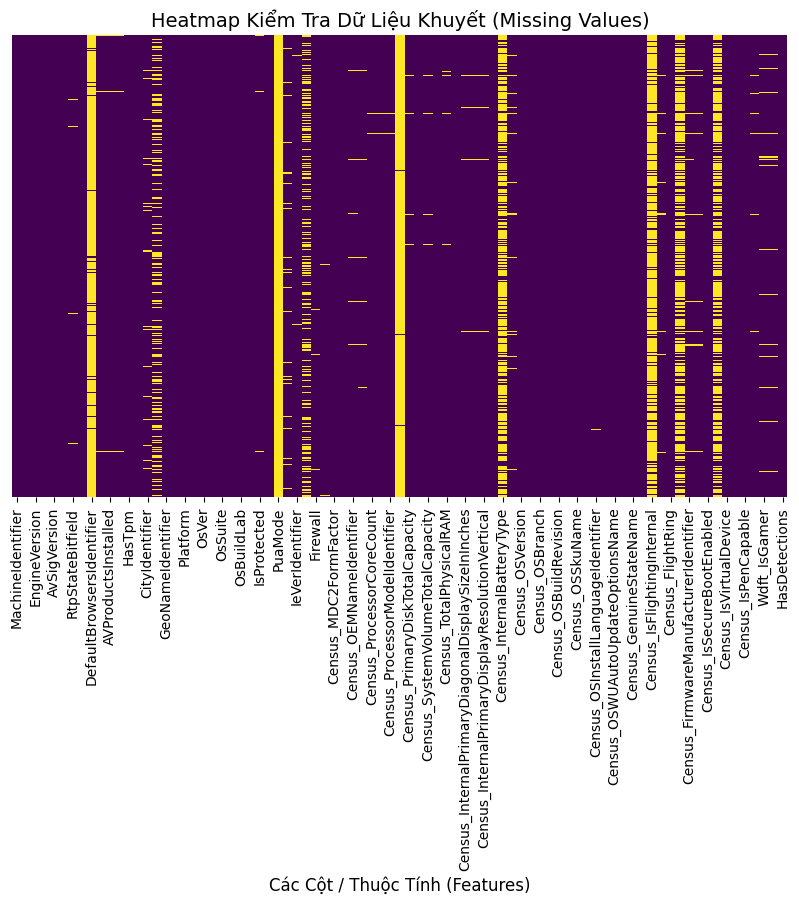

In [ ]:
# Missing Info
missing_ratio = df.isnull().mean().sort_values(ascending=False) * 100
print(missing_ratio[missing_ratio > 0])

plt.figure(figsize=(10, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis",
    yticklabels=False,
)

plt.title("Heatmap Kiểm Tra Dữ Liệu Khuyết (Missing Values)", fontsize=14)
plt.xlabel("Các Cột / Thuộc Tính (Features)", fontsize=12)
plt.show()

In [8]:
# Drop Collumns That Missing Data Over 50% - Those Data won't effect on training result cause number so small
cols_to_drop = missing_ratio[missing_ratio > 50].index.tolist()
print(f"Number of Drop Column: {len(cols_to_drop)}")
print(cols_to_drop)

df_clean = df.drop(columns=cols_to_drop)

# Drop ID column (not predictive)
id_cols = [c for c in ["MachineIdentifier"] if c in df_clean.columns]
df_clean = df_clean.drop(columns=id_cols)

Number of Drop Column: 7
['PuaMode', 'Census_ProcessorClass', 'DefaultBrowsersIdentifier', 'Census_IsFlightingInternal', 'Census_InternalBatteryType', 'Census_ThresholdOptIn', 'Census_IsWIMBootEnabled']


In [9]:
# Impute numeric using median
num_cols = df_clean.select_dtypes(include=["int64", "float64", "int8", "float32"]).columns.tolist()
# HasDetections Columns it's important to machine learning model learning detect malware so we should get it out while imputed num to not get loss data
if "HasDetections" in num_cols:
    num_cols.remove("HasDetections")

for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [10]:
# Impute categorical by explicit "Missing" category
cat_cols = df_clean.select_dtypes(include=["object", "category"]).columns.tolist()
for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna("Missing")

/tmp/ipykernel_235873/46725476.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_clean.select_dtypes(include=["object", "category"]).columns.tolist()


In [11]:
print(f"Remaining missing values: {df_clean.isnull().sum().sum()}")
print(f"Shape after cleaning: {df_clean.shape}")
df_clean

Remaining missing values: 0
Shape after cleaning: (20002, 75)


,ProductName,EngineVersion,AppVersion,AvSigVersion,IsBeta,RtpStateBitfield,IsSxsPassiveMode,AVProductStatesIdentifier,AVProductsInstalled,AVProductsEnabled,...,Census_FirmwareManufacturerIdentifier,Census_FirmwareVersionIdentifier,Census_IsSecureBootEnabled,Census_IsVirtualDevice,Census_IsTouchEnabled,Census_IsPenCapable,Census_IsAlwaysOnAlwaysConnectedCapable,Wdft_IsGamer,Wdft_RegionIdentifier,HasDetections
0,win8defender,1.1.15200.1,4.18.1807.18075,1.275.500.0,0,7.0,0,53447.0,1.0,1.0,...,142.0,35257.0,0,0.0,0,0,0.0,0.0,1.0,0
1,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1734.0,0,7.0,0,53447.0,1.0,1.0,...,789.0,8124.0,0,1.0,0,1,0.0,0.0,3.0,0
2,win8defender,1.1.15200.1,4.18.1807.18075,1.275.866.0,0,7.0,0,53447.0,1.0,1.0,...,355.0,6882.0,1,0.0,0,0,0.0,0.0,1.0,1
3,win8defender,1.1.15200.1,4.13.17134.1,1.273.1420.0,0,7.0,0,47238.0,2.0,1.0,...,628.0,13156.0,1,0.0,0,0,0.0,1.0,1.0,1
4,win8defender,1.1.13504.0,4.11.15063.1155,1.237.0.0,0,7.0,0,53447.0,1.0,1.0,...,628.0,13171.0,1,0.0,0,0,0.0,0.0,3.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19997,win8defender,1.1.15100.1,4.18.1807.18075,1.273.612.0,0,7.0,0,53447.0,1.0,1.0,...,500.0,16701.0,0,0.0,0,0,0.0,1.0,15.0,0
19998,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1642.0,0,7.0,0,53447.0,1.0,1.0,...,807.0,25262.0,1,0.0,0,0,0.0,0.0,1.0,1
19999,win8defender,1.1.15200.1,4.9.10586.873,1.275.59.0,0,7.0,0,53447.0,1.0,1.0,...,127.0,63122.0,0,0.0,0,0,0.0,0.0,15.0,1
20000,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1527.0,0,7.0,0,53447.0,1.0,1.0,...,355.0,20388.0,0,0.0,0,0,0.0,0.0,10.0,0


### 2.2 Handeling Imbalance

Label Encoding chosen over One-Hot because tree-based models Decision Tree / Random Forest) are not affected by artificial ordering, and several categorical columns have very high cardinality.

In [12]:
# Encode categorical variables
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    encoders[col] = le

print("Categorical encoding done (Label Encoding).")

#### Imbalance check (actual resampling happens after split, train-only)
print(f"\nClass imbalance ratio:\n{df_clean['HasDetections'].value_counts(normalize=True)}")
df_clean

Categorical encoding done (Label Encoding).

Class imbalance ratio:
HasDetections
1    0.5012
0    0.4988
Name: proportion, dtype: float64


,ProductName,EngineVersion,AppVersion,AvSigVersion,IsBeta,RtpStateBitfield,IsSxsPassiveMode,AVProductStatesIdentifier,AVProductsInstalled,AVProductsEnabled,...,Census_FirmwareManufacturerIdentifier,Census_FirmwareVersionIdentifier,Census_IsSecureBootEnabled,Census_IsVirtualDevice,Census_IsTouchEnabled,Census_IsPenCapable,Census_IsAlwaysOnAlwaysConnectedCapable,Wdft_IsGamer,Wdft_RegionIdentifier,HasDetections
0,1,36,27,1959,0,7.0,0,53447.0,1.0,1.0,...,142.0,35257.0,0,0.0,0,0,0.0,0.0,1.0,0
1,1,36,27,1820,0,7.0,0,53447.0,1.0,1.0,...,789.0,8124.0,0,1.0,0,1,0.0,0.0,3.0,0
2,1,36,27,2088,0,7.0,0,53447.0,1.0,1.0,...,355.0,6882.0,1,0.0,0,0,0.0,0.0,1.0,1
3,1,36,16,1340,0,7.0,0,47238.0,2.0,1.0,...,628.0,13156.0,1,0.0,0,0,0.0,1.0,1.0,1
4,1,9,10,82,0,7.0,0,53447.0,1.0,1.0,...,628.0,13171.0,1,0.0,0,0,0.0,0.0,3.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19997,1,35,27,1571,0,7.0,0,53447.0,1.0,1.0,...,500.0,16701.0,0,0.0,0,0,0.0,1.0,15.0,0
19998,1,35,27,1406,0,7.0,0,53447.0,1.0,1.0,...,807.0,25262.0,1,0.0,0,0,0.0,0.0,1.0,1
19999,1,36,62,1992,0,7.0,0,53447.0,1.0,1.0,...,127.0,63122.0,0,0.0,0,0,0.0,0.0,15.0,1
20000,1,36,27,1754,0,7.0,0,53447.0,1.0,1.0,...,355.0,20388.0,0,0.0,0,0,0.0,0.0,10.0,0


## 3. Feature Extraction

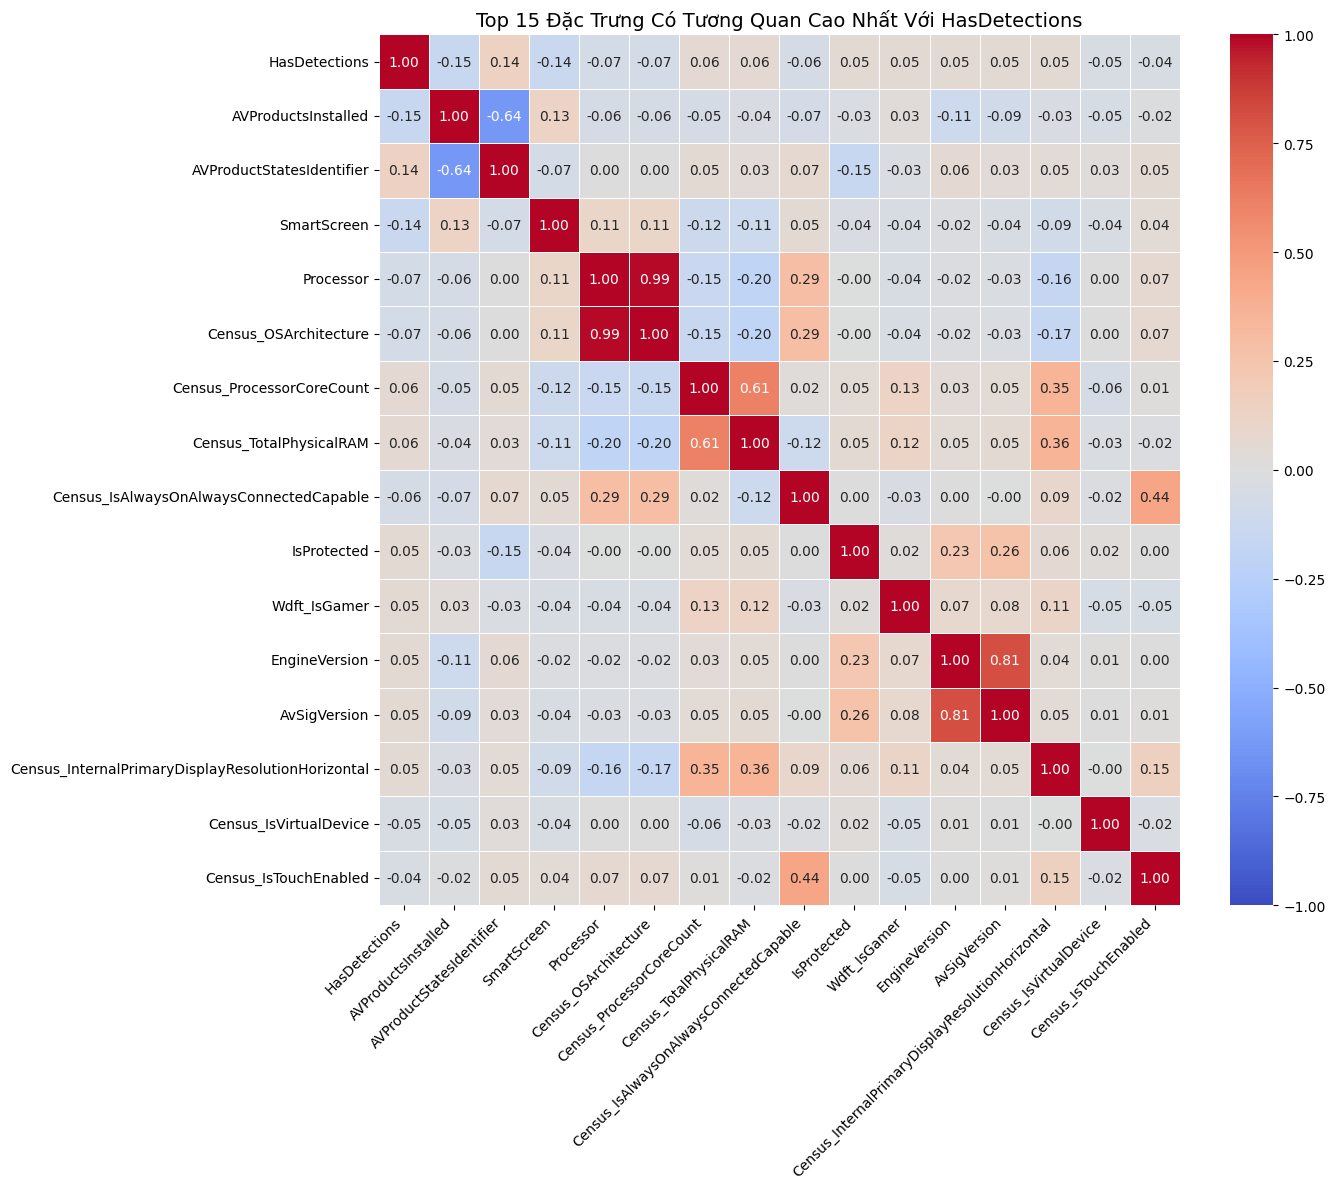

In [16]:
full_corr = df_clean.corr()
target_corr = full_corr["HasDetections"].abs()
top_features = target_corr.sort_values(ascending=False).head(16).index
sub_corr_matrix = df_clean[top_features].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    sub_corr_matrix,
    annot=True,  # Hiện số
    fmt=".2f",  # Làm tròn 2 chữ số
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)

plt.title(
    "Top 15 Đặc Trưng Có Tương Quan Cao Nhất Với HasDetections", fontsize=14
)
plt.xticks(rotation=45, ha="right")  # Xoay chữ trục X góc 45 độ cho dễ đọc
plt.yticks(rotation=0)  # Giữ trục Y nằm ngang
plt.tight_layout()
plt.show()

In [17]:
# Spilt label here for anti Data Leaking
X = df_clean.drop(columns=["HasDetections"])
y = df_clean["HasDetections"]
# Remove near-constant / low-variance features
selector = VarianceThreshold(threshold=0.01)
selector.fit(X)
selected_cols = X.columns[selector.get_support()]
removed_cols = X.columns[~selector.get_support()]

print(f"Removed {len(removed_cols)} low-variance columns: {list(removed_cols)}")
X = X[selected_cols]
print(f"Remaining features in X: {X.shape[1]}")

Removed 8 low-variance columns: ['IsBeta', 'AutoSampleOptIn', 'SMode', 'UacLuaenable', 'Census_DeviceFamily', 'Census_IsPortableOperatingSystem', 'Census_IsFlightsDisabled', 'Census_IsVirtualDevice']
Remaining features in X: 66


## 4. Model Training

### 4.1. Train/Test Split (80/20, stratified by y)

With stratify=y helps maintain the ratio between classes (Malware vs. Clean) in both the training and validation sets. 

In [27]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train shape: {X_train.shape} | Val shape: {X_val.shape}")
print(f"Train label dist:\n{y_train.value_counts(normalize=True)}")
print(f"Val label dist:\n{y_val.value_counts(normalize=True)}")

Train shape: (16001, 66) | Val shape: (4001, 66)
Train label dist:
HasDetections
1    0.501219
0    0.498781
Name: proportion, dtype: float64
Val label dist:
HasDetections
1    0.501125
0    0.498875
Name: proportion, dtype: float64


### 4.2. Model Training - Decision Tree (Baseline)

In [28]:
dt_model = DecisionTreeClassifier(
    class_weight="balanced", max_depth=15, random_state=42, criterion="entropy"
)

print("Training Decision Tree...")
dt_model.fit(X_train, y_train)

Training Decision Tree...


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

### 4.3. Model Training - Random Forest (ENSEMBLE)

In [29]:
rf_model = RandomForestClassifier(
    n_estimators=200, class_weight="balanced",
    max_depth=15, random_state=42, n_jobs=-1
)

print("Training Random Forest (ensemble)...")
rf_model.fit(X_train, y_train)

Training Random Forest (ensemble)...


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## 5. Compare Model

In [30]:
def evaluate(model, X_val, y_val, name):
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    cm = confusion_matrix(y_val, y_pred)

    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(classification_report(y_val, y_pred, target_names=["No Detection", "Detection"]))
    print(f"Confusion Matrix: \n{cm}")

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Detection", "Detection"],
                yticklabels=["No Detection", "Detection"])
    plt.title(f"Confusion Matrix - {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

--- Decision Tree ---
Accuracy : 0.5819
Precision: 0.5838
Recall   : 0.5766
F1-score : 0.5802
              precision    recall  f1-score   support

No Detection       0.58      0.59      0.58      1996
   Detection       0.58      0.58      0.58      2005

    accuracy                           0.58      4001
   macro avg       0.58      0.58      0.58      4001
weighted avg       0.58      0.58      0.58      4001

Confusion Matrix: 
[[1172  824]
 [ 849 1156]]


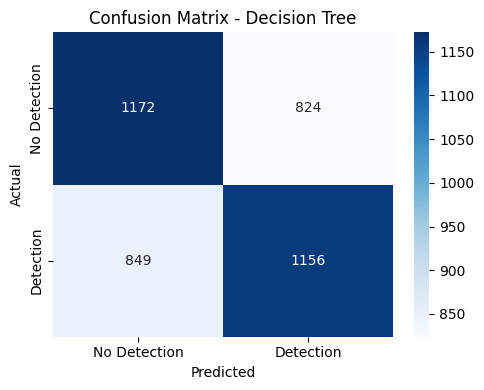

In [31]:
results = []
results.append(evaluate(dt_model, X_val, y_val, "Decision Tree"))

--- Random Forest ---
Accuracy : 0.6368
Precision: 0.6342
Recall   : 0.6504
F1-score : 0.6422
              precision    recall  f1-score   support

No Detection       0.64      0.62      0.63      1996
   Detection       0.63      0.65      0.64      2005

    accuracy                           0.64      4001
   macro avg       0.64      0.64      0.64      4001
weighted avg       0.64      0.64      0.64      4001

Confusion Matrix: 
[[1244  752]
 [ 701 1304]]


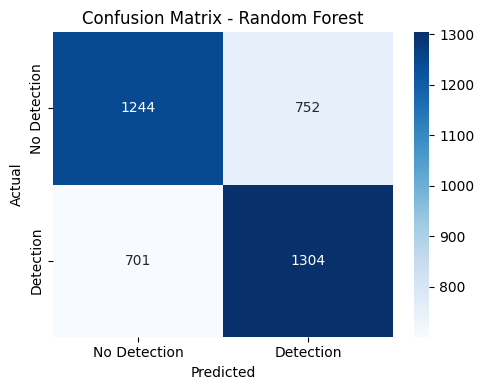

In [32]:
results.append(evaluate(rf_model, X_val, y_val, "Random Forest"))

In [33]:
print("=== Final Comparison ===")
pd.DataFrame(results)

=== Final Comparison ===


,model,accuracy,precision,recall,f1
0,Decision Tree,0.581855,0.583838,0.576559,0.580176
1,Random Forest,0.636841,0.634241,0.650374,0.642206
